# 7. Differential Abundance Analysis

### Notebook Structure

**1.** Data Exploration  
**2.** ANCOM  
&nbsp;&nbsp;&nbsp;&nbsp;**2.1** Delivery Mode  
&nbsp;&nbsp;&nbsp;&nbsp;**2.2** Diet  
&nbsp;&nbsp;&nbsp;&nbsp;**2.3** Age  
**3.** MaAsLin2  
**4.** DESeq2  
**5.** Consensus Set 

## Import data & packages

In [30]:
# 1 - Import packages
import os
import matplotlib.pyplot as plt
import pandas as pd
import qiime2 as q2
from qiime2 import Visualization
import seaborn as sns
from scipy.stats import shapiro, kruskal, f_oneway
import numpy as np
  
%matplotlib inline

In [3]:
# 2 - Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/scripts").


In [4]:
# 3 - Data directories
meta_data_dir = "../data/processed/metadata"
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
daa_data_dir = "../data/processed/differential_abundance"
# Create the new differential abundance analysis folder

In [4]:
%%bash -s "$daa_data_dir"
mkdir -p "$1"

# 1. Data Exploration: look at feature table and data distribution

We want to have a look at the feature table to check if it is sparse (a lot of zero-values) and to have a look at the data distribution. We can see in the table that there are quite a lot of zero-values and from the violin-plot we can see that the data is not normally distributed. We additionally did the Shapiro-Wilk test to check if the data is normally distributed, since we only plotted 15 samples. Further down in the results we can see that the data indeed is not normally distributed.

In [ ]:
#import and plot feature table to check for zero-values
data = q2.Artifact.load(f'{denoised_data_dir}/dada2_table.qza').view(pd.DataFrame)

In [ ]:
data.head()

In [ ]:
#violin plot to check if data is normally distributed
n = 15

# draw n ASVs out of the original DataFrame
data_samp = data.sample(n=n, axis=1, random_state=234)

# create a new DataFrame with three columns (sample, ASV, abundance)
col_names = {'level_0': 'sample', 'level_1': 'asv', 0: 'count'}
data_plot = data_samp.stack().reset_index().rename(columns=col_names)

# make sure the shape is correct (no. of rows should be equal to the size of our random 
# sample multiplied by number of samples)
assert data_plot.shape[0] == n * data_samp.shape[0], 'The new DataFrame has an incorrect no. of rows.'

In [ ]:
with sns.axes_style('white'), sns.color_palette('Set1'):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 7.5)
    
    sns.violinplot(data=data_plot, x='asv', y='count', ax=ax)
    sns.despine(left=True)
    
    # adjust tick labels and axes titles
    ax.tick_params(axis='x', rotation=90, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel('ASV', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

In [ ]:
#statistically testing for normality 
alpha = 0.05
results = {}

# iterate through rows (samples) and test each of them for normality
for asv_name, asv_values in data.items():
    stat, p = shapiro(asv_values)
    results[asv_name] = p

# convert test results into a DataFrame
results_df = pd.DataFrame(data=results.values(), index=results.keys(), columns=['p'])

# add a new column with a descriptive test result
results_df['is_normal'] = results_df['p'] > alpha

In [ ]:
results_df

In [ ]:
print('Number of ASVs with normal distribution:', results_df['is_normal'].sum())

# 2. ANCOM-BC
For the differential analysis we will use different methods and create a consensus set of differnetially abundant tax in the end. The first method that we use is ANCOM-BC, Analysis of Compositions of Microbiomes with Bias Correction, which is a rather conservative method when compared to other methods for differential abundance analysis. So it will set a good base for our consenus set [Nearing, J.T., Douglas, G.M., Hayes, M.G. et al. Microbiome differential abundance methods produce different results across 38 datasets. Nat Commun 13, 342 (2022)]. ANCOM-BC estimates the unknown sampling fractions and corrects the bias induced by their differences among samples. ANCOM uses relative abundances to infer about absolute abundances. One of the deficiencies of ANCOM is that it does not provide p value for individual taxon, nor can it provide standard errors or confidence intervals of DA for each taxon, and it can be computationally intensive [Lin, H., Peddada, S.D. Analysis of compositions of microbiomes with bias correction. Nat Commun 11, 3514 (2020)]. We performed ANCOM-BC for delivery mode (vaginal or cesarean) and for the infant's diet (milk-doiminant or formula-dominant).

## 2.1 Delivery Mode

In [5]:
# create ANCOM folder
!mkdir -p "$daa_data_dir/ANCOM"

In [6]:
# create folder for delivery mode
!mkdir -p "$daa_data_dir/ANCOM/delivery_mode"

In [5]:
! qiime feature-table filter-features \
    --i-table $denoised_data_dir/dada2_table.qza \
    --p-min-frequency 25 \
    --p-min-samples 4 \
    --o-filtered-table $daa_data_dir/table_abund.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/table_abund.qza


In [6]:
# add taxonomy
! qiime taxa collapse \
    --i-table $daa_data_dir/table_abund.qza \
    --i-taxonomy $taxonomy_data_dir/taxonomy.qza \
    --p-level 6 \
    --o-collapsed-table $daa_data_dir/table_abund_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/table_abund_l6.qza


In [7]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-where "[delivery_mode]='vaginal' or [delivery_mode]='cesarean'" \
    --o-filtered-table $daa_data_dir/ANCOM/delivery_mode/table_abund_deliverymode.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/ANCOM/delivery_mode/table_abund_deliverymode.qza


In [10]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/ANCOM/delivery_mode/table_abund_deliverymode.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-formula delivery_mode \
    --o-differentials $daa_data_dir/ANCOM/delivery_mode/ancombc_deliverymode_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/ANCOM/delivery_mode/ancombc_deliverymode_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/delivery_mode/ancombc_deliverymode_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/ANCOM/delivery_mode/ancombc_deliverymode_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/delivery_mode/ancombc_deliverymode_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/ANCOM/delivery_mode/ancombc_deliverymode_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/delivery_mode/ancombc_deliverymode_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pk

In [11]:
Visualization.load(f"{daa_data_dir}/ANCOM/delivery_mode/ancombc_deliverymode_da_barplot.qzv")

<visualization: Visualization uuid: 7fd50b5c-a32b-4159-8be2-27eb2ed5e134>

In [12]:
Visualization.load(f"{daa_data_dir}/ANCOM/delivery_mode/ancombc_deliverymode_results.qzv")

<visualization: Visualization uuid: 480d9bf6-eb8b-4221-a19a-ea9d72ad6df3>

## Volcano Plot

In [14]:
! qiime tools export \
      --input-path $daa_data_dir/ANCOM/delivery_mode/ancombc_deliverymode_differentials.qza \
      --output-path $daa_data_dir/ANCOM/delivery_mode/ancombc_export_deliverymode

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/ANCOM/delivery_mode/ancombc_deliverymode_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/differential_abundance/ANCOM/delivery_mode/ancombc_export_deliverymode


In [15]:
# Load exported ANCOM-BC tables
path = f"{daa_data_dir}/ANCOM/delivery_mode/ancombc_export_deliverymode/"

lfc = pd.read_csv(path + "lfc_slice.csv")
pval = pd.read_csv(path + "p_val_slice.csv")
qval = pd.read_csv(path + "q_val_slice.csv")
se   = pd.read_csv(path + "se_slice.csv")
w    = pd.read_csv(path + "w_slice.csv")

In [16]:
#merge output files into a single table
effect = "delivery_modevaginal"  

df_dm = (
    lfc[["id", effect]].rename(columns={effect: "lfc"})
    .merge(pval[["id", effect]].rename(columns={effect: "p_val"}), on="id")
    .merge(qval[["id", effect]].rename(columns={effect: "q_val"}), on="id")
    .merge(se[["id", effect]].rename(columns={effect: "se"}), on="id")
    .merge(w[["id", effect]].rename(columns={effect: "w"}), on="id")
)

df_dm["minus_log10_q"] = -np.log10(df_dm["q_val"] + 1e-300)  # avoid log(0)

df_dm.head()

,id,lfc,p_val,q_val,se,w,minus_log10_q
0,d__Bacteria;p__Actinomycetota;c__Actinobacteri...,-0.634323,1.195419e-01,1.000000e+00,0.407479,-1.556699,-0.000000
1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,0.807373,1.810436e-01,1.000000e+00,0.603621,1.337549,-0.000000
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,3.845995,4.574429e-13,2.836146e-11,0.531407,7.237378,10.547271
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,-0.802619,1.757956e-01,1.000000e+00,0.592857,-1.353814,-0.000000
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...,-0.176278,7.581944e-01,1.000000e+00,0.572605,-0.307853,-0.000000


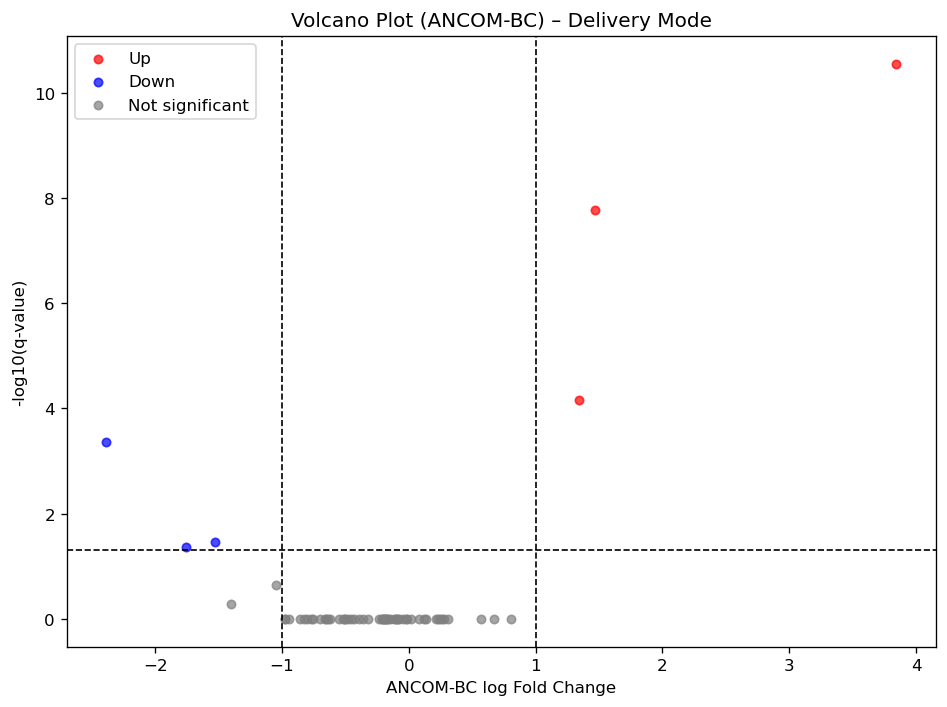

In [17]:
# df = merged ANCOM-BC dataframe
df_dm = df_dm.dropna(subset=["q_val", "lfc"])

# Significance thresholds
alpha = 0.05           # q-value cutoff
lfc_thresh = 1         # effect size cutoff (adjust as needed)

df_dm["-log10_q"] = -np.log10(df_dm["q_val"] + 1e-300)  # to avoid log(0)

# Categorize points
df_dm["sig"] = "Not significant"
df_dm.loc[(df_dm["q_val"] < alpha) & (df_dm["lfc"] >= lfc_thresh), "sig"] = "Up"
df_dm.loc[(df_dm["q_val"] < alpha) & (df_dm["lfc"] <= -lfc_thresh), "sig"] = "Down"

colors = {
    "Up": "red",
    "Down": "blue",
    "Not significant": "grey"
}

plt.figure(figsize=(8,6), dpi=120)

for cat, color in colors.items():
    subset = df_dm[df_dm["sig"] == cat]
    plt.scatter(
        subset["lfc"],
        subset["-log10_q"],
        s=25,
        label=cat,
        c=color,
        alpha=0.7
    )

# Add threshold lines
plt.axvline(x=lfc_thresh, color="black", linestyle="--", linewidth=1)
plt.axvline(x=-lfc_thresh, color="black", linestyle="--", linewidth=1)
plt.axhline(y=-np.log10(alpha), color="black", linestyle="--", linewidth=1)

plt.xlabel("ANCOM-BC log Fold Change")
plt.ylabel("-log10(q-value)")
plt.title("Volcano Plot (ANCOM-BC) – Delivery Mode")
plt.legend()
plt.tight_layout()
plt.show()


## 2.2 Diet Milk

In [35]:
# create folder for diet
!mkdir -p "$daa_data_dir/ANCOM/diet"

In [36]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-where "[diet_milk]='bd' or [diet_milk]='fd'" \
    --o-filtered-table $daa_data_dir/ANCOM/diet/table_abund_diet.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/ANCOM/diet/table_abund_diet.qza


In [16]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/ANCOM/diet/table_abund_diet.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-formula diet_milk \
    --o-differentials $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/diet/ancombc_diet_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/diet/ancombc_diet_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/ANCOM/diet/ancombc_diet_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/diet/ancombc_diet_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an AP

In [43]:
Visualization.load(f"{daa_data_dir}/ANCOM/diet/ancombc_diet_da_barplot.qzv")

<visualization: Visualization uuid: 9801bad2-e057-4337-b489-6c6c7cb9d15f>

In [44]:
Visualization.load(f"{daa_data_dir}/ANCOM/diet/ancombc_diet_results.qzv")

<visualization: Visualization uuid: b48a2525-d259-476c-9d86-e7812b4eb838>

## Volcano Plot

In [45]:
! qiime tools export \
      --input-path $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
      --output-path $daa_data_dir/ANCOM/diet/ancombc_export_diet

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/ANCOM/diet/ancombc_diet_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/differential_abundance/ANCOM/diet/ancombc_export_diet


In [47]:
# Load exported ANCOM-BC tables
path = f"{daa_data_dir}/ANCOM/diet/ancombc_export_diet/"

lfc = pd.read_csv(path + "lfc_slice.csv")
pval = pd.read_csv(path + "p_val_slice.csv")
qval = pd.read_csv(path + "q_val_slice.csv")
se   = pd.read_csv(path + "se_slice.csv")
w    = pd.read_csv(path + "w_slice.csv")

In [50]:
#merge output files into a single table
effect = "diet_milkfd"  

df_d = (
    lfc[["id", effect]].rename(columns={effect: "lfc"})
    .merge(pval[["id", effect]].rename(columns={effect: "p_val"}), on="id")
    .merge(qval[["id", effect]].rename(columns={effect: "q_val"}), on="id")
    .merge(se[["id", effect]].rename(columns={effect: "se"}), on="id")
    .merge(w[["id", effect]].rename(columns={effect: "w"}), on="id")
)

df_d["minus_log10_q"] = -np.log10(df_d["q_val"] + 1e-300)  # avoid log(0)

df_d.head()

,id,lfc,p_val,q_val,se,w,minus_log10_q
0,35ffcc3b809d667286737d79670b8de5,0.474496,0.525024,1.000000,0.746508,0.635620,-0.000000
1,d46e2205f0c6ecf67b51f83d111c509c,1.767110,0.012985,0.921907,0.711342,2.484191,0.035313
2,2c982937754e6321f861027032db80f7,-0.357313,0.602917,1.000000,0.686863,-0.520211,-0.000000
3,99deb3c5ecb022ec05609ebd1112a557,0.337883,0.602509,1.000000,0.648782,0.520796,-0.000000
4,fd44d4cb468fd7dc9b3227867714ed87,-1.620417,0.018253,1.000000,0.686486,-2.360452,-0.000000


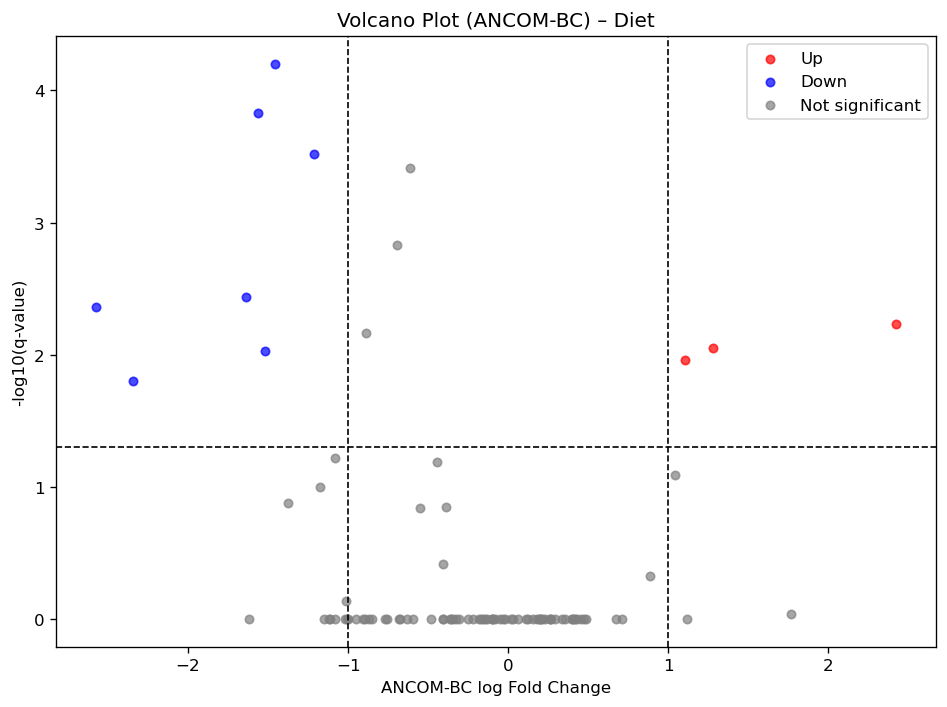

In [54]:
# df = merged ANCOM-BC dataframe
df_d = df_d.dropna(subset=["q_val", "lfc"])

# Significance thresholds
alpha = 0.05           # q-value cutoff
lfc_thresh = 1         # effect size cutoff (adjust as needed)

df_d["-log10_q"] = -np.log10(df_d["q_val"] + 1e-300)  # to avoid log(0)

# Categorize points
df_d["sig"] = "Not significant"
df_d.loc[(df_d["q_val"] < alpha) & (df_d["lfc"] >= lfc_thresh), "sig"] = "Up"
df_d.loc[(df_d["q_val"] < alpha) & (df_d["lfc"] <= -lfc_thresh), "sig"] = "Down"

colors = {
    "Up": "red",
    "Down": "blue",
    "Not significant": "grey"
}

plt.figure(figsize=(8,6), dpi=120)

for cat, color in colors.items():
    subset = df_d[df_d["sig"] == cat]
    plt.scatter(
        subset["lfc"],
        subset["-log10_q"],
        s=25,
        label=cat,
        c=color,
        alpha=0.7
    )

# Add threshold lines
plt.axvline(x=lfc_thresh, color="black", linestyle="--", linewidth=1)
plt.axvline(x=-lfc_thresh, color="black", linestyle="--", linewidth=1)
plt.axhline(y=-np.log10(alpha), color="black", linestyle="--", linewidth=1)

plt.xlabel("ANCOM-BC log Fold Change")
plt.ylabel("-log10(q-value)")
plt.title("Volcano Plot (ANCOM-BC) – Diet")
plt.legend()
plt.tight_layout()
plt.show()


## 2.3 Age (months)

In [7]:
# create folder for age
!mkdir -p "$daa_data_dir/ANCOM/age"

In [20]:
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# Add a prefix so values cannot be parsed as numbers
meta["age_group"] = meta["age_months"].astype(str).str.replace('.0', '', regex=False)
meta["age_group"] = "m" + meta["age_group"]   # m4, m7, m10

meta.to_csv(f"{daa_data_dir}/metadata_age_str.tsv", sep="\t", index=False)


In [21]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $daa_data_dir/metadata_age_str.tsv \
    --p-where "[age_group]='m4' OR [age_group]='m10'" \
    --o-filtered-table $daa_data_dir/ANCOM/age/table_abund_age.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/ANCOM/age/table_abund_age.qza


In [22]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/ANCOM/age/table_abund_age.qza \
    --m-metadata-file $daa_data_dir/metadata_age_str.tsv \
    --p-formula age_group \
    --p-reference-levels age_group::m4 \
    --o-differentials $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/ANCOM/age/ancombc_age_differentials.qza


In [23]:
# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/age/ancombc_age_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/age/ancombc_age_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/age/ancombc_age_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/age/ancombc_age_results.qzv


In [26]:
Visualization.load(f"{daa_data_dir}/ANCOM/age/ancombc_age_da_barplot.qzv")

<visualization: Visualization uuid: faf76c15-9450-4625-93bb-6c796e30b43f>

In [27]:
Visualization.load(f"{daa_data_dir}/ANCOM/age/ancombc_age_results.qzv")

<visualization: Visualization uuid: c30135dd-dd0f-4dcb-8ea6-c574d92c96e8>

## Volcano Plot

In [28]:
! qiime tools export \
      --input-path $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
      --output-path $daa_data_dir/ANCOM/age/ancombc_export_age

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/ANCOM/age/ancombc_age_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/differential_abundance/ANCOM/age/ancombc_export_age


In [32]:
# Load exported ANCOM-BC tables
path = f"{daa_data_dir}/ANCOM/age/ancombc_export_age/"

lfc = pd.read_csv(path + "lfc_slice.csv")
pval = pd.read_csv(path + "p_val_slice.csv")
qval = pd.read_csv(path + "q_val_slice.csv")
se   = pd.read_csv(path + "se_slice.csv")
w    = pd.read_csv(path + "w_slice.csv")

In [34]:
#merge output files into a single table
effect = "age_groupm10"  

df_a = (
    lfc[["id", effect]].rename(columns={effect: "lfc"})
    .merge(pval[["id", effect]].rename(columns={effect: "p_val"}), on="id")
    .merge(qval[["id", effect]].rename(columns={effect: "q_val"}), on="id")
    .merge(se[["id", effect]].rename(columns={effect: "se"}), on="id")
    .merge(w[["id", effect]].rename(columns={effect: "w"}), on="id")
)

df_a["minus_log10_q"] = -np.log10(df_a["q_val"] + 1e-300)  # avoid log(0)

df_a.head()

,id,lfc,p_val,q_val,se,w,minus_log10_q
0,d__Bacteria;p__Actinomycetota;c__Actinobacteri...,-0.346894,0.283037,1.000000,0.323136,-1.073523,-0.000000
1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,-1.358978,0.002264,0.067931,0.445103,-3.053173,1.167934
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,-0.089563,0.852406,1.000000,0.481391,-0.186050,-0.000000
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,1.090714,0.006269,0.163000,0.399038,2.733358,0.787813
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactoba...,-1.096762,0.003028,0.087078,0.369918,-2.964880,1.060092


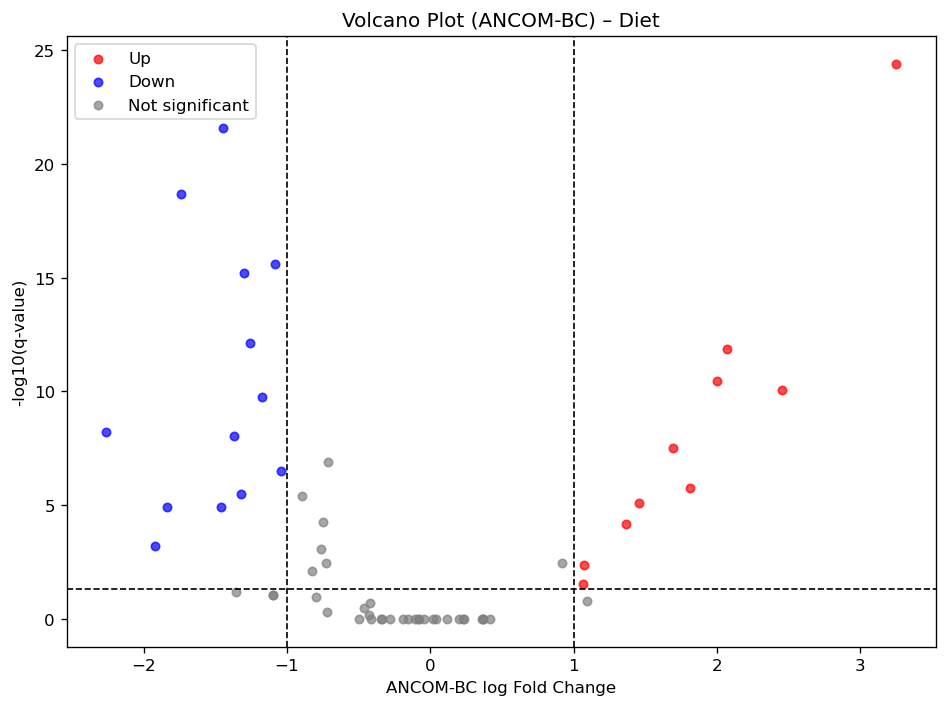

In [35]:
# df = merged ANCOM-BC dataframe
df_a = df_a.dropna(subset=["q_val", "lfc"])

# Significance thresholds
alpha = 0.05           # q-value cutoff
lfc_thresh = 1         # effect size cutoff (adjust as needed)

df_a["-log10_q"] = -np.log10(df_a["q_val"] + 1e-300)  # to avoid log(0)

# Categorize points
df_a["sig"] = "Not significant"
df_a.loc[(df_a["q_val"] < alpha) & (df_a["lfc"] >= lfc_thresh), "sig"] = "Up"
df_a.loc[(df_a["q_val"] < alpha) & (df_a["lfc"] <= -lfc_thresh), "sig"] = "Down"

colors = {
    "Up": "red",
    "Down": "blue",
    "Not significant": "grey"
}

plt.figure(figsize=(8,6), dpi=120)

for cat, color in colors.items():
    subset = df_a[df_a["sig"] == cat]
    plt.scatter(
        subset["lfc"],
        subset["-log10_q"],
        s=25,
        label=cat,
        c=color,
        alpha=0.7
    )

# Add threshold lines
plt.axvline(x=lfc_thresh, color="black", linestyle="--", linewidth=1)
plt.axvline(x=-lfc_thresh, color="black", linestyle="--", linewidth=1)
plt.axhline(y=-np.log10(alpha), color="black", linestyle="--", linewidth=1)

plt.xlabel("ANCOM-BC log Fold Change")
plt.ylabel("-log10(q-value)")
plt.title("Volcano Plot (ANCOM-BC) – Diet")
plt.legend()
plt.tight_layout()
plt.show()


# 4. MaAsLin2
https://github.com/biobakery/Maaslin2

The second method we use is MaAsLin2. It has shown to be identify more differentially abundant taxa than ANCOM, but also to be consistent across different datasets. MaAsLin2 finds associations between microbiome multi-omics features and complex metadata in population-scale epidemiological studies. The software includes multiple analysis methods (including support for multiple covariates and repeated measures), filtering, normalization, and transform options.

In [ ]:
! qiime tools export \
    --input-path $daa_data_dir/table_abund_l6.qza \
    --output-path $daa_data_dir/table_abund_l6_export

In [ ]:
! biom convert \
    -i $daa_data_dir/table_abund_l6_export/feature-table.biom \
    -o $daa_data_dir/table_abund_l6_export/feature-table.tsv \
    --to-tsv

In [12]:
# enable R in Jupyter Notebook
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


The following cell needs to be run every time and takes about 1 hour.

In [ ]:
%%R
install.packages("BiocManager")
BiocManager::install("Maaslin2")

In [28]:
%%R
library(Maaslin2)

fit <- Maaslin2(
    input_data = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/table_abund_l6_export/feature-table.tsv",
    input_metadata = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/metadata/metadata_merged.tsv",
    output = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output",
    normalization = "TSS",
    transform = "LOG",
    analysis_method = "LM",
    fixed_effects = c("age_months", "delivery_mode", "diet_milk", "geo_location_name", "diet_weaning", "treatment_exposure"),
    random_effects = c("host_id")
)

[1] "Creating output folder"
[1] "Creating output feature tables folder"
[1] "Creating output fits folder"
[1] "Creating output figures folder"
2025-12-01 13:58:32.723903 INFO::Writing function arguments to log file
2025-12-01 13:58:32.81026 INFO::Verifying options selected are valid
2025-12-01 13:58:32.843613 INFO::Determining format of input files
2025-12-01 13:58:32.847577 INFO::Input format is data samples as columns and metadata samples as rows
2025-12-01 13:58:33.030266 INFO::Formula for random effects: expr ~ (1 | host_id)
2025-12-01 13:58:33.034364 INFO::Formula for fixed effects: expr ~  age_months
2025-12-01 13:58:33.037614 INFO::Filter data based on min abundance and min prevalence
2025-12-01 13:58:33.040433 INFO::Total samples in data: 357
2025-12-01 13:58:33.042863 INFO::Min samples required with min abundance for a feature not to be filtered: 35.700000
2025-12-01 13:58:33.04955 INFO::Total filtered features: 117
2025-12-01 13:58:33.052557 INFO::Filtered feature names from

R[write to console]: boundary (singular) fit: see help('isSingular')



  |++++++++++++++++++++++++++++++++++++++++++        | 84% ~01s          2025-12-01 13:58:39.027078 INFO::Fitting model to feature number 53, d__Bacteria.p__Pseudomonadota.c__Gammaproteobacteria.o__Burkholderiales.f__Neisseriaceae.g__Neisseria
  |+++++++++++++++++++++++++++++++++++++++++++       | 85% ~01s          2025-12-01 13:58:39.106272 INFO::Fitting model to feature number 54, d__Bacteria.p__Pseudomonadota.c__Gammaproteobacteria.o__Pseudomonadales.f__Pseudomonadaceae.g__Pseudomonas
  |++++++++++++++++++++++++++++++++++++++++++++      | 87% ~01s          2025-12-01 13:58:39.178381 INFO::Fitting model to feature number 55, d__Bacteria.p__Bacillota.c__Clostridia.o__Oscillospirales.f__Ruminococcaceae.__
  |+++++++++++++++++++++++++++++++++++++++++++++     | 89% ~01s          2025-12-01 13:58:39.246084 INFO::Fitting model to feature number 56, d__Bacteria.p__Fusobacteriota.c__Fusobacteriia.o__Fusobacteriales.f__Fusobacteriaceae.g__Fusobacterium
  |+++++++++++++++++++++++++++++++++++++

R[write to console]: boundary (singular) fit: see help('isSingular')



  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=05s  
2025-12-01 13:58:39.808194 INFO::Counting total values for each feature
2025-12-01 13:58:39.816208 INFO::Writing filtered data to file /home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output_age/features/filtered_data.tsv
2025-12-01 13:58:39.840904 INFO::Writing filtered, normalized data to file /home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output_age/features/filtered_data_norm.tsv
2025-12-01 13:58:39.864793 INFO::Writing filtered, normalized, transformed data to file /home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output_age/features/filtered_data_norm_transformed.tsv
2025-12-01 13:58:39.925327 INFO::Writing residuals to file /home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output_age/fits/residuals.rds
2025-12-01 

R[write to console]: Error: <ggplot2::labels> object is invalid:
- every label must be named.

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the Maaslin2 package.
  Please report the issue at <https://github.com/biobakery/maaslin2/issues>.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 




Error: <ggplot2::labels> object is invalid:
- every label must be named.


RInterpreterError: Failed to parse and evaluate line 'library(Maaslin2)\n\nfit <- Maaslin2(\n    input_data = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/table_abund_l6_export/feature-table.tsv",\n    input_metadata = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/raw/metadata.tsv",\n    output = "/home/jovyan/Project/MicrobiomeAnalysis_TummyTribe/data/processed/differential_abundance/maaslin2_output_age",\n    normalization = "TSS",\n    transform = "LOG",\n    analysis_method = "LM",\n    fixed_effects = c("age_months"),\n    random_effects = c("host_id")\n)\n'.
R error message: 'Error: <ggplot2::labels> object is invalid:\n- every label must be named.'

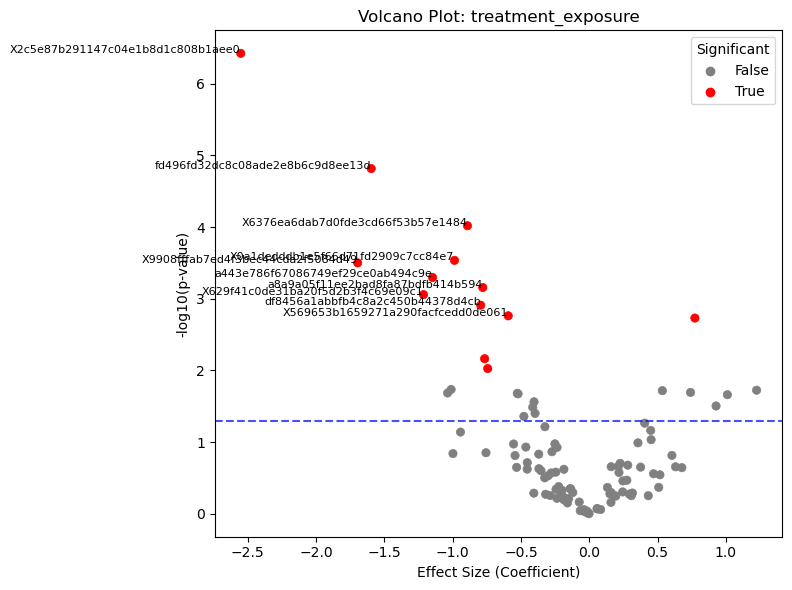

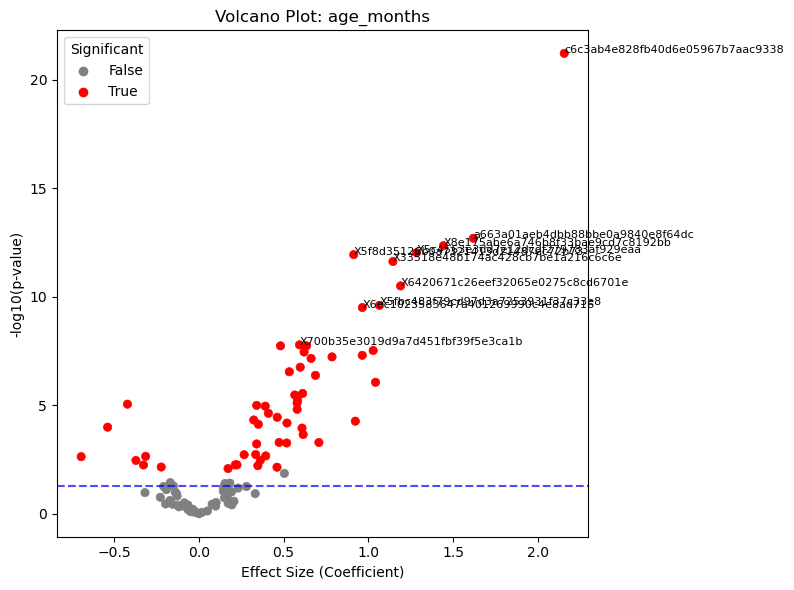

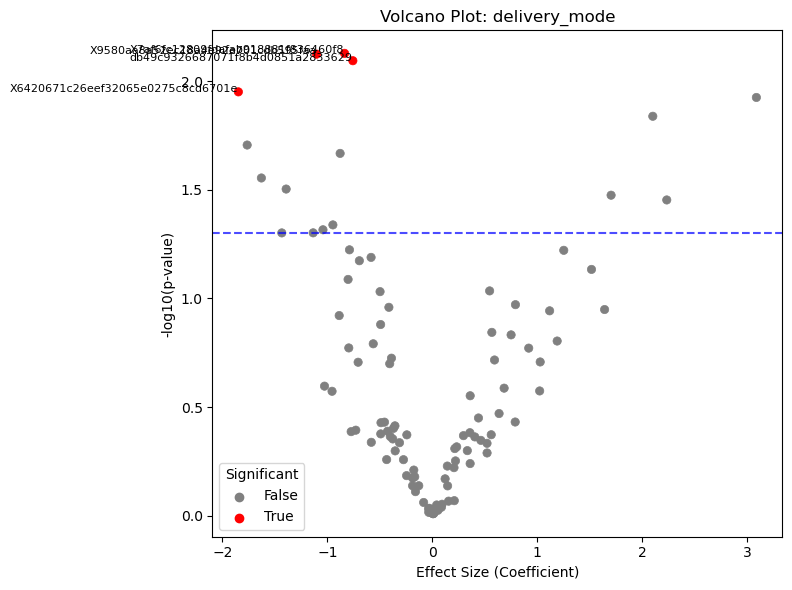

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Maaslin2 results
results = pd.read_csv(
    f"{daa_data_dir}/maaslin2_output/all_results.tsv",
    sep="\t"
)
# Function to create a volcano plot for a specific metadata variable
def volcano_plot(df, metadata_var, qval_threshold=0.05, top_n=10):
    # Filter for the metadata variable
    df_meta = df[df['metadata'] == metadata_var].copy()
    
    # Calculate -log10 p-value
    df_meta['neg_log10_pval'] = -np.log10(df_meta['pval'])
    
    # Define significance
    df_meta['significant'] = df_meta['qval'] < qval_threshold
    
    # Plot
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=df_meta, 
        x='coef', 
        y='neg_log10_pval', 
        hue='significant',
        palette={True:'red', False:'grey'},
        edgecolor=None
    )
    
    # Label top hits by absolute effect size among significant hits
    top_hits = df_meta[df_meta['significant']].nlargest(top_n, 'neg_log10_pval')
    for _, row in top_hits.iterrows():
        plt.text(row['coef'], row['neg_log10_pval'], row['feature'],
                 fontsize=8, ha='right' if row['coef'] < 0 else 'left')
    
    plt.axhline(-np.log10(qval_threshold), linestyle='--', color='blue', alpha=0.7)
    plt.xlabel('Effect Size (Coefficient)')
    plt.ylabel('-log10(p-value)')
    plt.title(f'Volcano Plot: {metadata_var}')
    plt.legend(title='Significant')
    plt.tight_layout()
    plt.show()


# Volcano plots
volcano_plot(results, metadata_var="treatment_exposure")
volcano_plot(results, metadata_var="age_months")
volcano_plot(results, metadata_var="delivery_mode")
volcano_plot(results, metadata_var="diet_milk")
volcano_plot(results, metadata_var="geo_location_name")
volcano_plot(results, metadata_var="diet_weaning")

# 5. DESeq2

https://bioconductor.org/packages//release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html

The third method we will use is DESeq2. It provides methods to test for differential expression by use of negative binomial generalized linear models; the estimates of dispersion and logarithmic fold changes incorporate data-driven prior distributions.

In [ ]:
# create folder for delivery mode
!mkdir -p "$daa_data_dir/DESeq2"

In [16]:
# Load the feature table (TSV)
feature_table = pd.read_csv(f"{daa_data_dir}/table_abund_l6_export/feature-table.tsv", sep="\t", skiprows=1)
feature_table = feature_table.rename(columns={"#OTU ID": "Taxon"})

# Set taxonomy as the index
feature_table = feature_table.set_index("Taxon")

# Load metadata
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t", index_col=0)

In [17]:
counts = feature_table  # taxonomy as rows, samples as columns

# Match metadata samples
shared = meta.index.intersection(counts.columns)

counts = counts[shared]
meta = meta.loc[shared]

print(counts.shape, meta.shape)

(179, 357) (357, 8)


In [14]:
# run R in Jupyter notebook
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


The following cell needs to be run every time and takes about 1 hour.

In [ ]:
%%R
install.packages("BiocManager")
BiocManager::install("DESeq2")

In [18]:
%%R -i counts -i meta -i daa_data_dir

library(DESeq2)

# Filter low-abundance taxa
keep <- rowSums(counts) > 5
counts_filtered <- counts[keep, ]

# Create DESeq2 object
dds <- DESeqDataSetFromMatrix(
  countData = counts_filtered,
  colData = meta_clean,
  design = ~ treatment_exposure
)

# Use poscounts to handle zero-inflation
dds <- estimateSizeFactors(dds, type = "poscounts")

# Run DESeq2
dds <- DESeq(dds)
res <- results(dds)

# Convert to data.frame
res_df <- as.data.frame(res)
res_df$Taxon <- rownames(res_df)

# Build output path in R
out_path <- file.path(daa_data_dir, "DESeq2", "results_deseq2_treatment.tsv")

# Ensure directory exists
dir.create(file.path(daa_data_dir, "DESeq2"), showWarnings = FALSE, recursive = TRUE)

# Save results
write.table(
  res_df,
  file = out_path,
  sep = "\t",
  quote = FALSE,
  row.names = TRUE
)

R[write to console]: Error in library(DESeq2) : there is no package called ‘DESeq2’

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package ‘Maaslin2’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages 




Error in library(DESeq2) : there is no package called ‘DESeq2’


RInterpreterError: Failed to parse and evaluate line '\nlibrary(DESeq2)\n\n# Filter low-abundance taxa\nkeep <- rowSums(counts) > 5\ncounts_filtered <- counts[keep, ]\n\n# Create DESeq2 object\ndds <- DESeqDataSetFromMatrix(\n  countData = counts_filtered,\n  colData = meta_clean,\n  design = ~ treatment_exposure\n)\n\n# Use poscounts to handle zero-inflation\ndds <- estimateSizeFactors(dds, type = "poscounts")\n\n# Run DESeq2\ndds <- DESeq(dds)\nres <- results(dds)\n\n# Convert to data.frame\nres_df <- as.data.frame(res)\nres_df$Taxon <- rownames(res_df)\n\n# Build output path in R\nout_path <- file.path(daa_data_dir, "DESeq2", "results_deseq2_treatment.tsv")\n\n# Ensure directory exists\ndir.create(file.path(daa_data_dir, "DESeq2"), showWarnings = FALSE, recursive = TRUE)\n\n# Save results\nwrite.table(\n  res_df,\n  file = out_path,\n  sep = "\\t",\n  quote = FALSE,\n  row.names = TRUE\n)\n'.
R error message: 'Error in library(DESeq2) : there is no package called ‘DESeq2’'

## Volcano plots

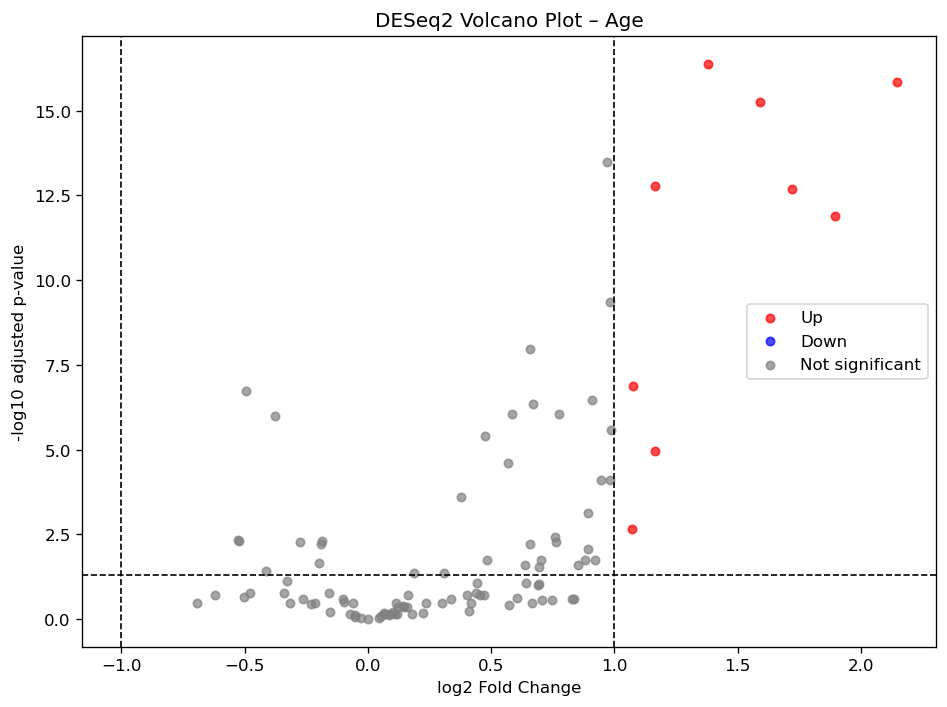

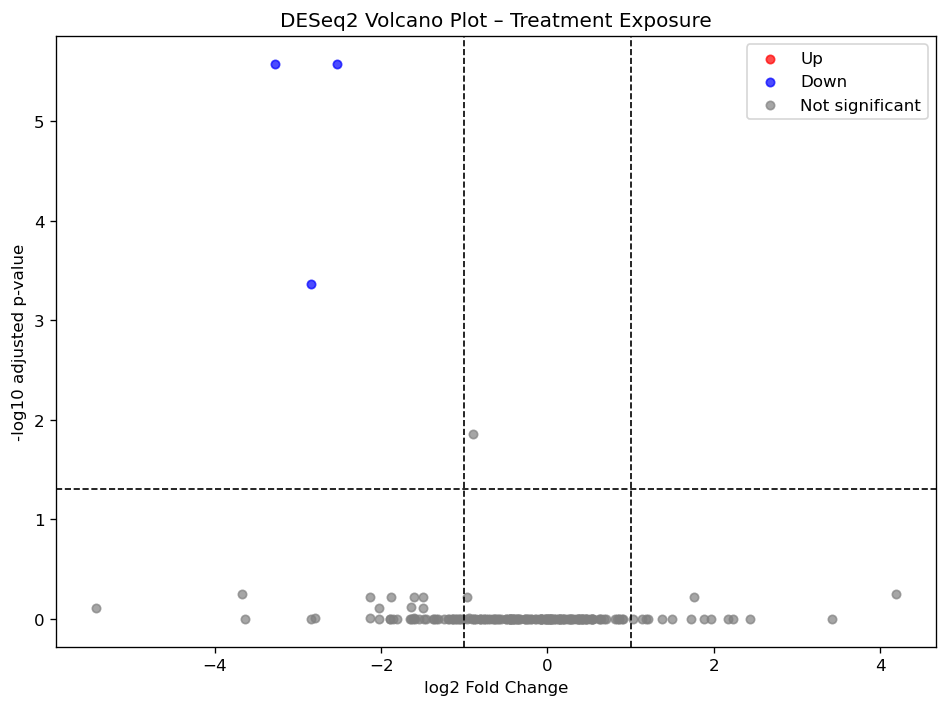

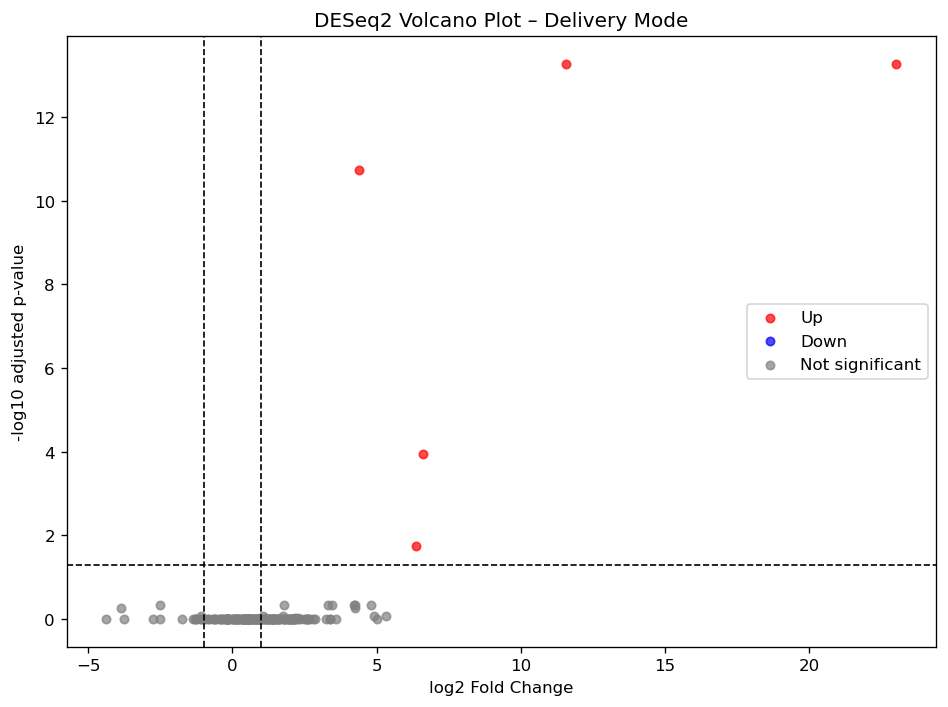

In [34]:
def plot_volcano(df_path, alpha=0.05, lfc_thresh=1, top_n=10, title=None, dpi=120):
    """
    Generate a volcano plot from a DESeq2 results file with optional top N labeling.
    
    Parameters:
    - df_path: str, path to the DESeq2 results TSV
    - alpha: float, adjusted p-value threshold for significance
    - lfc_thresh: float, log2 fold change threshold
    - top_n: int, number of top significant features to label
    - title: str, optional plot title
    - dpi: int, figure dpi
    """
    # Load data
    df = pd.read_csv(df_path, sep="\t")
    
    # Remove rows with missing padj or log2FoldChange
    df = df.dropna(subset=["padj", "log2FoldChange"])
    
    # Compute -log10(padj)
    df["-log10_padj"] = -np.log10(df["padj"])
    
    # Categorize points
    df["sig"] = "Not significant"
    df.loc[(df["padj"] < alpha) & (df["log2FoldChange"] >= lfc_thresh), "sig"] = "Up"
    df.loc[(df["padj"] < alpha) & (df["log2FoldChange"] <= -lfc_thresh), "sig"] = "Down"
    
    # Define colors
    colors = {"Up": "red", "Down": "blue", "Not significant": "grey"}
    
    # Plot points
    plt.figure(figsize=(8,6), dpi=dpi)
    for cat, color in colors.items():
        subset = df[df["sig"] == cat]
        plt.scatter(
            subset["log2FoldChange"],
            subset["-log10_padj"],
            s=25,
            label=cat,
            c=color,
            alpha=0.7
        )
    
    # Threshold lines
    plt.axvline(x=lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axvline(x=-lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axhline(y=-np.log10(alpha), color="black", linestyle="--", linewidth=1)
    
    """
    # Label top N significant features
    sig_df = df[df["sig"] != "Not significant"]
    if not sig_df.empty and top_n > 0:
        # Rank by -log10(padj) and absolute log2FoldChange
        sig_df["rank_score"] = sig_df["-log10_padj"] * abs(sig_df["log2FoldChange"])
        top_hits = sig_df.nlargest(top_n, "rank_score")
        for _, row in top_hits.iterrows():
            plt.text(row["log2FoldChange"], row["-log10_padj"], row["feature"],
                     fontsize=8, ha="right" if row["log2FoldChange"] < 0 else "left")
    """
    
    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10 adjusted p-value")
    if title is None:
        title = f"Volcano Plot – {df_path.split('/')[-1]}"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_volcano(
    df_path=f"{daa_data_dir}/DESeq2/results_deseq2_age.tsv",
    alpha=0.05,
    lfc_thresh=1,
    top_n=10,
    title="DESeq2 Volcano Plot – Age"
)
plot_volcano(
    df_path=f"{daa_data_dir}/DESeq2/results_deseq2_treatment.tsv",
    alpha=0.05,
    lfc_thresh=1,
    top_n=10,
    title="DESeq2 Volcano Plot – Treatment Exposure"
)
plot_volcano(
    df_path=f"{daa_data_dir}/DESeq2/results_deseq2_deliverymode.tsv",
    alpha=0.05,
    lfc_thresh=1,
    top_n=10,
    title="DESeq2 Volcano Plot – Delivery Mode"
)
